# 🏡 Smart House Price Prediction

## 📘 Notebook 1: Data Understanding & Exploratory Data Analysis (EDA)

---

## 🎯 Objective

The objective of this notebook is to perform a comprehensive exploratory data analysis (EDA) on the Ames Housing dataset. Understanding the dataset is a critical first step in developing a robust machine learning pipeline.

This notebook focuses on identifying the dataset characteristics, data quality issues, feature distributions, missing values, and relationships between variables. The insights obtained during this stage will guide feature engineering, preprocessing strategies, and model selection in the subsequent notebooks.

---

## 📂 Dataset

**Dataset:** Ames Housing Dataset

**Target Variable:** `SalePrice`

The dataset contains detailed information describing residential properties, including structural characteristics, neighborhood information, quality assessments, and sale prices.

---

## 📋 Notebook Workflow

This notebook is organized into the following sections:

1. Import Required Libraries
2. Load the Dataset
3. Dataset Overview
4. Missing Value Analysis
5. Duplicate Record Analysis
6. Data Type Analysis
7. Target Variable Analysis
8. Correlation Analysis
9. Exploratory Data Analysis
10. Key Observations and Conclusions

---

## 📌 Expected Outcomes

By the end of this notebook, we will have:

- A complete understanding of the dataset structure.
- Identification of missing values and data quality issues.
- Statistical summaries of numerical variables.
- Analysis of categorical and numerical features.
- Exploration of relationships with the target variable.
- Insights that will inform preprocessing and feature engineering in the next notebook.

In [3]:
# ============================================================
# Import Required Libraries
# ============================================================

# Standard Library
import os
import sys
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Display Options
from IPython.display import display

# Notebook Configuration
warnings.filterwarnings("ignore")
%matplotlib inline

# ============================================================
# Display Settings
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


In [4]:
# ============================================================
# Visualization Configuration
# ============================================================

# Figure Settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

# Font Settings
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# Grid Settings
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("=" * 60)
print("Notebook configuration completed successfully.")
print("=" * 60)


Notebook configuration completed successfully.


In [5]:
# ============================================================
# Project Root Configuration
# ============================================================

# Get the current notebook directory
NOTEBOOK_DIR = os.getcwd()

# Project root (one level above the notebooks folder)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define commonly used project directories
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
NOTEBOOKS_DIR = os.path.join(PROJECT_ROOT, "notebooks")
UTILS_DIR = os.path.join(PROJECT_ROOT, "backend", "utils")

print("=" * 60)
print("Project Root Configuration")
print("=" * 60)
print(f"Project Root : {PROJECT_ROOT}")
print(f"Raw Data     : {RAW_DATA_DIR}")
print(f"Processed    : {PROCESSED_DATA_DIR}")
print(f"Models       : {MODELS_DIR}")
print(f"Utils        : {UTILS_DIR}")


Project Root Configuration
Project Root : c:\Users\HP\AI Projects\Smart-House-Price-Prediction
Raw Data     : c:\Users\HP\AI Projects\Smart-House-Price-Prediction\data\raw
Processed    : c:\Users\HP\AI Projects\Smart-House-Price-Prediction\data\processed
Models       : c:\Users\HP\AI Projects\Smart-House-Price-Prediction\models
Utils        : c:\Users\HP\AI Projects\Smart-House-Price-Prediction\backend\utils


## 📂 Load the Ames Housing Dataset

With the project environment configured, we now load the training dataset into a Pandas DataFrame.

This step verifies that the dataset is accessible and prepares it for exploratory data analysis.

### Objectives

- Load the training dataset from the project directory.
- Verify that the dataset exists.
- Store the dataset in a DataFrame (`df`).
- Display the dataset dimensions.
- Confirm that the dataset has been loaded successfully.

### Dataset Location

```
data/
└── raw/
    └── train.csv
```

The loaded DataFrame (`df`) will be used throughout this notebook for data exploration and statistical analysis.

In [6]:
# ============================================================
# Load the Training Dataset
# ============================================================

# Construct dataset path
train_data_path = os.path.join(RAW_DATA_DIR, "train.csv")

# Verify file existence
if not os.path.exists(train_data_path):
    raise FileNotFoundError(
        f"Dataset not found!\nExpected location:\n{train_data_path}"
    )

# Load dataset
df = pd.read_csv(train_data_path)

# ============================================================
# Dataset Loading Summary
# ============================================================

rows, cols = df.shape
memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)
print(f"Dataset Name   : Ames Housing Training Dataset")
print(f"Location       : {train_data_path}")
print(f"Rows           : {rows:,}")
print(f"Columns        : {cols}")
print(f"Memory Usage   : {memory_usage:.2f} MB")
print("=" * 60)

# Display first five records
display(df.head())


Dataset Loaded Successfully
Dataset Name   : Ames Housing Training Dataset
Location       : c:\Users\HP\AI Projects\Smart-House-Price-Prediction\data\raw\train.csv
Rows           : 1,460
Columns        : 81
Memory Usage   : 3.43 MB


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 📊 Dataset Overview

Before performing detailed exploratory data analysis, it is essential to understand the overall structure of the dataset.

This section provides a high-level overview by examining:

- Dataset preview
- Dataset dimensions
- Feature names
- Data types
- Basic statistical summary

These checks help verify that the dataset has been loaded correctly and provide initial insights into its structure before deeper analysis.

In [7]:
# ============================================================
# Dataset Preview
# ============================================================

print("=" * 60)
print("First Five Records")
print("=" * 60)

display(df.head())

print("\n")

print("=" * 60)
print("Last Five Records")
print("=" * 60)

display(df.tail())


First Five Records


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




Last Five Records


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.00,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.00,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.00,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.00,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.00,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.00,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.00,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.00,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.00,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.00,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.00,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.00,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.00,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [8]:
# ============================================================
# Dataset Dimensions
# ============================================================

rows, columns = df.shape

dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Total Observations"
    ],
    "Value": [
        f"{rows:,}",
        columns,
        f"{rows * columns:,}"
    ]
})

print("=" * 60)
print("Dataset Dimensions")
print("=" * 60)

display(dataset_summary.style.hide(axis="index"))


Dataset Dimensions


Metric,Value
Number of Rows,"1,460"
Number of Columns,81
Total Observations,"118,260"


In [9]:
# ============================================================
# Feature (Column) Information
# ============================================================

feature_summary = pd.DataFrame({
    "Feature Name": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values,
    "Missing (%)": (df.isnull().mean() * 100).values
})

print("=" * 70)
print(f"Total Features : {len(df.columns)}")
print("=" * 70)

display(feature_summary.style.format({"Missing (%)": "{:.2f}"}).hide(axis="index"))


Total Features : 81


Feature Name,Data Type,Unique Values,Missing Values,Missing (%)
Id,int64,1460,0,0.00
MSSubClass,int64,15,0,0.00
MSZoning,str,5,0,0.00
LotFrontage,float64,110,259,17.74
LotArea,int64,1073,0,0.00
Street,str,2,0,0.00
Alley,str,2,1369,93.77
LotShape,str,4,0,0.00
LandContour,str,4,0,0.00
Utilities,str,2,0,0.00


In [10]:
# ============================================================
# Dataset Information Summary
# ============================================================

numerical_features = df.select_dtypes(include=["number"]).shape[1]
categorical_features = df.select_dtypes(include=["object", "string"]).shape[1]
boolean_features = df.select_dtypes(include=["bool"]).shape[1]

total_missing = int(df.isnull().sum().sum())
duplicate_rows = int(df.duplicated().sum())

memory_usage = (
    df.memory_usage(deep=True).sum() / (1024 ** 2)
)

completeness = (
    (1 - total_missing / (df.shape[0] * df.shape[1])) * 100
)

summary = pd.DataFrame({
    "Property": [
        "Rows",
        "Columns",
        "Numerical Features",
        "Categorical Features",
        "Boolean Features",
        "Duplicate Rows",
        "Total Missing Values",
        "Dataset Completeness (%)",
        "Memory Usage (MB)",
        "Target Variable"
    ],
    "Value": [
        f"{df.shape[0]:,}",
        df.shape[1],
        numerical_features,
        categorical_features,
        boolean_features,
        duplicate_rows,
        f"{total_missing:,}",
        f"{completeness:.2f}%",
        f"{memory_usage:.2f}",
        "SalePrice"
    ]
})

print("=" * 70)
print("Dataset Information Summary")
print("=" * 70)

display(summary.style.hide(axis="index"))


Dataset Information Summary


Property,Value
Rows,"1,460"
Columns,81
Numerical Features,38
Categorical Features,43
Boolean Features,0
Duplicate Rows,0
Total Missing Values,"7,829"
Dataset Completeness (%),93.38%
Memory Usage (MB),3.43
Target Variable,SalePrice


In [11]:
# ============================================================
# Statistical Summary of Numerical Features
# ============================================================

print("=" * 70)
print("Statistical Summary - Numerical Features")
print("=" * 70)

numerical_summary = df.describe().T

# Add additional statistics
numerical_summary["Missing Values"] = df.isnull().sum()
numerical_summary["Missing (%)"] = (
    df.isnull().mean() * 100
).round(2)

display(
    numerical_summary.style
    .format({
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:.2f}",
        "25%": "{:.2f}",
        "50%": "{:.2f}",
        "75%": "{:.2f}",
        "max": "{:.2f}",
        "Missing (%)": "{:.2f}"
    })
)


Statistical Summary - Numerical Features


,count,mean,std,min,25%,50%,75%,max,Missing Values,Missing (%)
Id,1460.000000,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00,0,0.00
MSSubClass,1460.000000,56.90,42.30,20.00,20.00,50.00,70.00,190.00,0,0.00
LotFrontage,1201.000000,70.05,24.28,21.00,59.00,69.00,80.00,313.00,259,17.74
LotArea,1460.000000,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00,0,0.00
OverallQual,1460.000000,6.10,1.38,1.00,5.00,6.00,7.00,10.00,0,0.00
OverallCond,1460.000000,5.58,1.11,1.00,5.00,5.00,6.00,9.00,0,0.00
YearBuilt,1460.000000,1971.27,30.20,1872.00,1954.00,1973.00,2000.00,2010.00,0,0.00
YearRemodAdd,1460.000000,1984.87,20.65,1950.00,1967.00,1994.00,2004.00,2010.00,0,0.00
MasVnrArea,1452.000000,103.69,181.07,0.00,0.00,0.00,166.00,1600.00,8,0.55
BsmtFinSF1,1460.000000,443.64,456.10,0.00,0.00,383.50,712.25,5644.00,0,0.00


# 3. Missing Value Analysis

Missing values are one of the most critical aspects of data quality assessment. Before performing feature engineering or model training, it is important to identify the extent and distribution of missing data across the dataset.

In this section, we will:

- Identify features containing missing values.
- Calculate the total number and percentage of missing values.
- Rank features based on missingness.
- Determine which features require imputation, transformation, or removal during the data preprocessing stage.

This analysis provides valuable insights that guide the data cleaning strategy adopted in the subsequent notebook.

In [12]:
# ============================================================
# Missing Value Summary
# ============================================================

missing_summary = (
    pd.DataFrame({
        "Feature": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing (%)": (df.isnull().mean() * 100).values,
        "Data Type": df.dtypes.values
    })
    .query("`Missing Values` > 0")
    .sort_values("Missing Values", ascending=False)
    .reset_index(drop=True)
)

# Categorize missingness severity
def classify_missing(pct):
    if pct >= 90:
        return "Critical"
    elif pct >= 50:
        return "High"
    elif pct >= 10:
        return "Moderate"
    else:
        return "Low"

missing_summary["Severity"] = (
    missing_summary["Missing (%)"]
    .apply(classify_missing)
)

print("=" * 70)
print(f"Features with Missing Values: {len(missing_summary)}")
print("=" * 70)

display(
    missing_summary.style
    .format({
        "Missing (%)": "{:.2f}"
    })
    .hide(axis="index")
)


Features with Missing Values: 19


Feature,Missing Values,Missing (%),Data Type,Severity
PoolQC,1453,99.52,str,Critical
MiscFeature,1406,96.30,str,Critical
Alley,1369,93.77,str,Critical
Fence,1179,80.75,str,High
MasVnrType,872,59.73,str,High
FireplaceQu,690,47.26,str,Moderate
LotFrontage,259,17.74,float64,Moderate
GarageType,81,5.55,str,Low
GarageYrBlt,81,5.55,float64,Low
GarageFinish,81,5.55,str,Low


# 4. Duplicate Data Analysis

Duplicate observations can introduce bias into statistical analysis and machine learning models by overrepresenting certain data points. Therefore, it is important to identify and quantify duplicate records before proceeding with data preprocessing.

In this section, we will:

- Detect duplicate observations in the dataset.
- Quantify the total number of duplicate records.
- Determine whether duplicate removal is necessary before feature engineering and model development.

In [13]:
# ============================================================
# Duplicate Record Analysis
# ============================================================

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("=" * 60)
print(f"Total Records           : {len(df)}")
print(f"Duplicate Records       : {duplicate_count}")
print(f"Duplicate Percentage    : {duplicate_percentage:.2f}%")
print("=" * 60)

if duplicate_count == 0:
    print("✅ No duplicate records were found in the dataset.")
else:
    print(f"⚠️ {duplicate_count} duplicate records should be considered for removal.")


Total Records           : 1460
Duplicate Records       : 0
Duplicate Percentage    : 0.00%
✅ No duplicate records were found in the dataset.


# 5. Data Type Analysis

Understanding the distribution of feature data types is an important step in exploratory data analysis, as it determines the appropriate preprocessing and feature engineering techniques required for different variables.

In this section, we will:

- Identify numerical and categorical features.
- Summarize the distribution of data types.
- Assess the dataset structure to support subsequent preprocessing and model development.

In [14]:
# ============================================================
# Feature Type Summary
# ============================================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).shape[1]
categorical_features = df.select_dtypes(include=["object", "category", "string"]).shape[1]
boolean_features = df.select_dtypes(include=["bool"]).shape[1]

feature_summary = pd.DataFrame({
    "Feature Type": [
        "Numerical",
        "Categorical",
        "Boolean",
        "Total Features"
    ],
    "Count": [
        numerical_features,
        categorical_features,
        boolean_features,
        df.shape[1]
    ]
})

display(
    feature_summary.style.hide(axis="index")
)


Feature Type,Count
Numerical,38
Categorical,43
Boolean,0
Total Features,81


In [15]:
# ============================================================
# Store Numerical and Categorical Feature Lists
# ============================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")


Numerical Features   : 38
Categorical Features : 43


# 6. Target Variable Analysis

The target variable, **SalePrice**, represents the selling price of each house and is the prediction target for this regression problem. Analyzing its distribution and statistical properties is essential for understanding the dataset and selecting appropriate modeling techniques.

In this section, we will:

- Examine the descriptive statistics of the target variable.
- Analyze its distribution and central tendency.
- Assess skewness and the presence of potential outliers.
- Identify whether any transformation (e.g., logarithmic transformation) may be beneficial before model training.

In [16]:
# ============================================================
# Target Variable Summary Statistics
# ============================================================

saleprice_summary = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "25th Percentile",
        "75th Percentile",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["SalePrice"].count(),
        df["SalePrice"].mean(),
        df["SalePrice"].median(),
        df["SalePrice"].std(),
        df["SalePrice"].min(),
        df["SalePrice"].quantile(0.25),
        df["SalePrice"].quantile(0.75),
        df["SalePrice"].max(),
        df["SalePrice"].skew(),
        df["SalePrice"].kurt()
    ]
})

display(
    saleprice_summary.style.format({
        "Value": lambda x: f"{x:,.2f}"
    }).hide(axis="index")
)


Statistic,Value
Count,"1,460.00"
Mean,"180,921.20"
Median,"163,000.00"
Standard Deviation,"79,442.50"
Minimum,"34,900.00"
25th Percentile,"129,975.00"
75th Percentile,"214,000.00"
Maximum,"755,000.00"
Skewness,1.88
Kurtosis,6.54


### Key Observations

The statistical summary of the target variable reveals several important characteristics:

- The average house price is **180,921**, while the median is **163,000**, indicating a right-skewed distribution.
- The **standard deviation (79,442)** suggests considerable variability in house prices.
- The **maximum sale price (755,000)** is substantially higher than the upper quartile (214,000), indicating the presence of high-value properties.
- The **positive skewness (1.88)** and **high kurtosis (6.54)** suggest that the target variable deviates from a normal distribution and contains extreme values.
- These observations indicate that a logarithmic transformation of the target variable may improve distributional symmetry and benefit regression model performance.

# 7. Correlation Analysis

Correlation analysis is an important step in exploratory data analysis for regression problems, as it measures the strength and direction of linear relationships between numerical features and the target variable (**SalePrice**). Understanding these relationships helps identify influential predictors and provides guidance for feature selection and engineering.

In this section, we will:

- Compute the correlation coefficients between numerical features and the target variable.
- Identify the features that exhibit the strongest positive and negative correlations with **SalePrice**.
- Highlight potential multicollinearity among numerical features.
- Use the findings to support feature selection and model development.

In [17]:
# ============================================================
# Correlation Analysis with Target Variable (SalePrice)
# ============================================================

# Compute correlation matrix for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Extract correlations with the target variable
saleprice_correlation = (
    correlation_matrix["SalePrice"]
    .drop("SalePrice")  # Remove self-correlation
    .to_frame(name="Correlation Coefficient")
)

# Compute absolute correlation for ranking feature strength
saleprice_correlation["Correlation Strength"] = (
    saleprice_correlation["Correlation Coefficient"].abs()
)

# Rank features by the magnitude of their correlation with SalePrice
saleprice_correlation = saleprice_correlation.sort_values(
    by="Correlation Strength",
    ascending=False
)

# Display formatted table
display(
    saleprice_correlation.style.format({
        "Correlation Coefficient": "{:.3f}",
        "Correlation Strength": "{:.3f}"
    })
)


,Correlation Coefficient,Correlation Strength
OverallQual,0.791,0.791
GrLivArea,0.709,0.709
GarageCars,0.640,0.640
GarageArea,0.623,0.623
TotalBsmtSF,0.614,0.614
1stFlrSF,0.606,0.606
FullBath,0.561,0.561
TotRmsAbvGrd,0.534,0.534
YearBuilt,0.523,0.523
YearRemodAdd,0.507,0.507


### Key Observations

The correlation analysis evaluates the linear relationship between the numerical features and the target variable (**SalePrice**). The **Correlation Strength** represents the absolute value of the Pearson correlation coefficient and is used to rank features according to the magnitude of their linear association with the target variable, regardless of whether the relationship is positive or negative.

#### Major Findings

- **OverallQual** has the highest **Correlation Strength (0.791)** and the strongest positive correlation (**0.791**) with **SalePrice**, indicating that the overall quality of construction and materials is the most influential numerical predictor of house prices.

- **GrLivArea (0.709)**, **GarageCars (0.640)**, **GarageArea (0.623)**, **TotalBsmtSF (0.614)**, and **1stFlrSF (0.606)** also demonstrate strong positive correlations, suggesting that larger living spaces, greater garage capacity, and increased basement area are strongly associated with higher property values.

- Features including **FullBath (0.561)**, **TotRmsAbvGrd (0.534)**, **YearBuilt (0.523)**, **YearRemodAdd (0.507)**, **GarageYrBlt (0.486)**, **MasVnrArea (0.477)**, and **Fireplaces (0.467)** exhibit moderate positive correlations, indicating that house quality, age, renovation history, and additional amenities contribute meaningfully to selling price.

- Features such as **LotFrontage (0.352)**, **WoodDeckSF (0.324)**, **2ndFlrSF (0.319)**, **OpenPorchSF (0.316)**, **HalfBath (0.284)**, and **LotArea (0.264)** show relatively weaker positive relationships, suggesting that they provide supplementary predictive information but are less influential than the top-ranked variables.

- The strongest negative correlations are observed for **KitchenAbvGr (-0.136)**, **EnclosedPorch (-0.129)**, and **MSSubClass (-0.084)**. However, their comparatively low **Correlation Strength** values indicate that no numerical feature exhibits a strong inverse linear relationship with **SalePrice**.

- Variables such as **MoSold**, **3SsnPorch**, **YrSold**, **LowQualFinSF**, **Id**, **MiscVal**, **BsmtHalfBath**, and **BsmtFinSF2** have correlation coefficients close to zero, indicating little or no meaningful linear association with the target variable.

#### Conclusion

Overall, the analysis indicates that **construction quality**, **living area**, **garage capacity**, **basement size**, and **overall property dimensions** are the strongest numerical predictors of house prices in the Ames Housing dataset. These features are expected to play a significant role during feature engineering and predictive model development.

Although Pearson correlation is effective for identifying linear relationships, it does not imply causation and does not capture non-linear dependencies. Therefore, these findings will be complemented with feature engineering techniques and model-based feature importance analysis during the model development stage.

## 8.1 Exploratory Analysis of Key Features

This subsection examines selected numerical and categorical features that exhibit significant missing values or are considered important based on the initial data quality assessment and correlation analysis. The objective is to better understand their distributions, category frequencies, and overall characteristics before any preprocessing is performed.

The analysis focuses on:

- **PoolQC** to examine the distribution of pool quality categories.
- **Alley** to understand the availability of alley access across properties.
- **GarageType** to investigate the distribution of different garage configurations.
- **LotFrontage** to analyze the distribution of lot frontage measurements and identify potential skewness or unusual values.

The insights obtained from this analysis provide a clearer understanding of these important features and establish a foundation for subsequent exploratory analyses within the dataset.

Pool Quality (PoolQC)


,Count,Percentage (%)
PoolQC,,
NaN,1453,99.52
Gd,3,0.21
Ex,2,0.14
Fa,2,0.14


Alley Access


,Count,Percentage (%)
Alley,,
NaN,1369,93.77
Grvl,50,3.42
Pave,41,2.81


Garage Type


,Count,Percentage (%)
GarageType,,
Attchd,870,59.59
Detchd,387,26.51
BuiltIn,88,6.03
NaN,81,5.55
Basment,19,1.30
CarPort,9,0.62
2Types,6,0.41


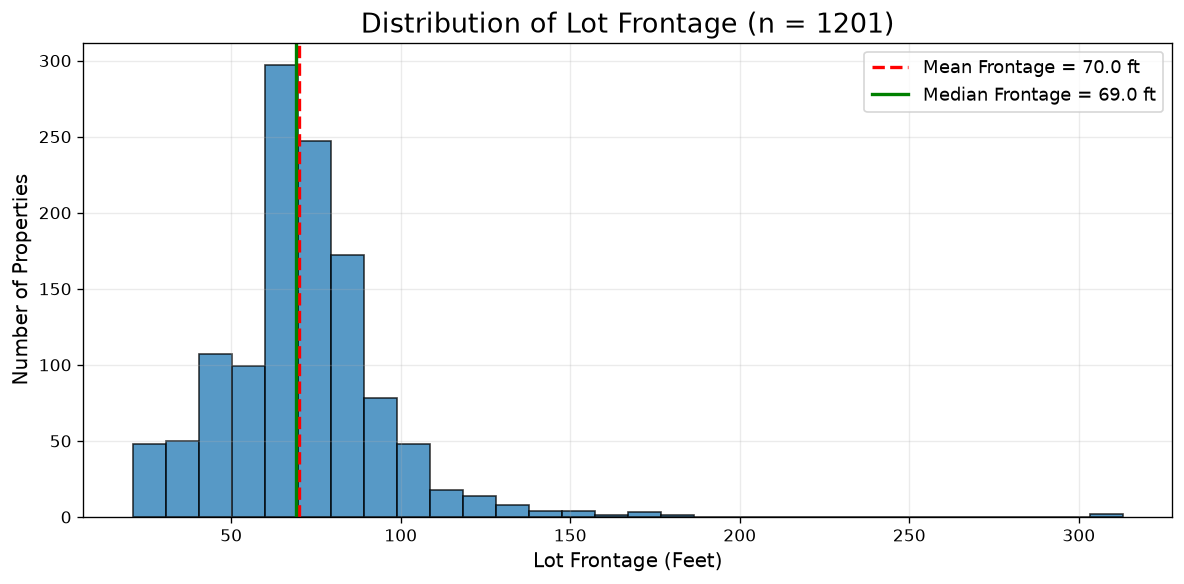

In [18]:
# ============================================================
# Exploratory Analysis of Key Features
# ============================================================

def frequency_table(column):
    """Generate frequency table with counts and percentages."""
    return pd.DataFrame({
        "Count": df[column].value_counts(dropna=False),
        "Percentage (%)": (
            df[column]
            .value_counts(dropna=False, normalize=True)
            * 100
        ).round(2)
    })

# Pool Quality
print("=" * 80)
print("Pool Quality (PoolQC)")
print("=" * 80)
display(frequency_table("PoolQC"))

# Alley
print("=" * 80)
print("Alley Access")
print("=" * 80)
display(frequency_table("Alley"))

# Garage Type
print("=" * 80)
print("Garage Type")
print("=" * 80)
display(frequency_table("GarageType"))

# LotFrontage Distribution

lot_frontage = df["LotFrontage"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    lot_frontage,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

# Mean line
plt.axvline(
    lot_frontage.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Frontage = {lot_frontage.mean():.1f} ft"
)

# Median line
plt.axvline(
    lot_frontage.median(),
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median Frontage = {lot_frontage.median():.1f} ft"
)

plt.title(
    f"Distribution of Lot Frontage (n = {len(lot_frontage)})",
    fontsize=16
)

plt.xlabel("Lot Frontage (Feet)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()


## 8.2 Masonry Veneer Analysis

This subsection examines the masonry veneer features present in the dataset to better understand their distributions, category frequencies, and numerical characteristics. Masonry veneer is an important exterior feature that contributes to both the aesthetic appeal and structural characteristics of residential properties. Analyzing these variables provides valuable insights into their variability and the prevalence of missing observations within the dataset.

The analysis focuses on:

- **MasVnrType** to examine the distribution of different masonry veneer types across residential properties.
- **MasVnrArea** to analyze the distribution of masonry veneer area and identify its overall characteristics, including central tendency and variability.

The insights obtained from this analysis provide a deeper understanding of masonry-related features and establish a foundation for subsequent exploratory analyses of other important property characteristics.

Masonry Veneer Type (MasVnrType)


,Count,Percentage (%)
MasVnrType,,
NaN,872,59.73
BrkFace,445,30.48
Stone,128,8.77
BrkCmn,15,1.03


Masonry Veneer Area - Descriptive Statistics


,MasVnrArea Statistics
count,1452.00
mean,103.69
std,181.07
min,0.00
25%,0.00
50%,0.00
75%,166.00
max,1600.00


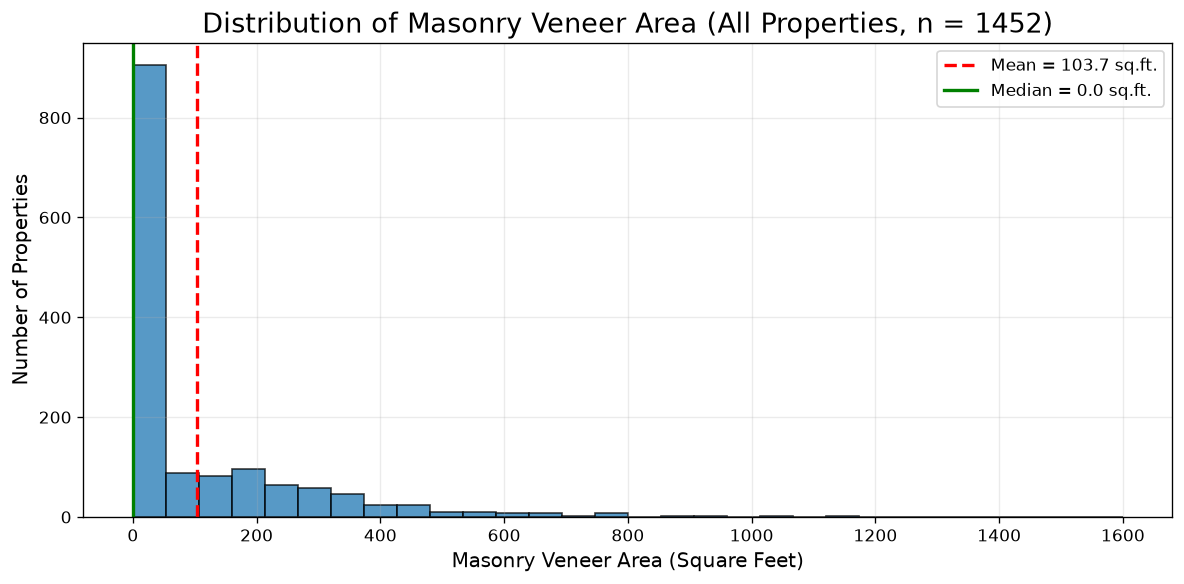

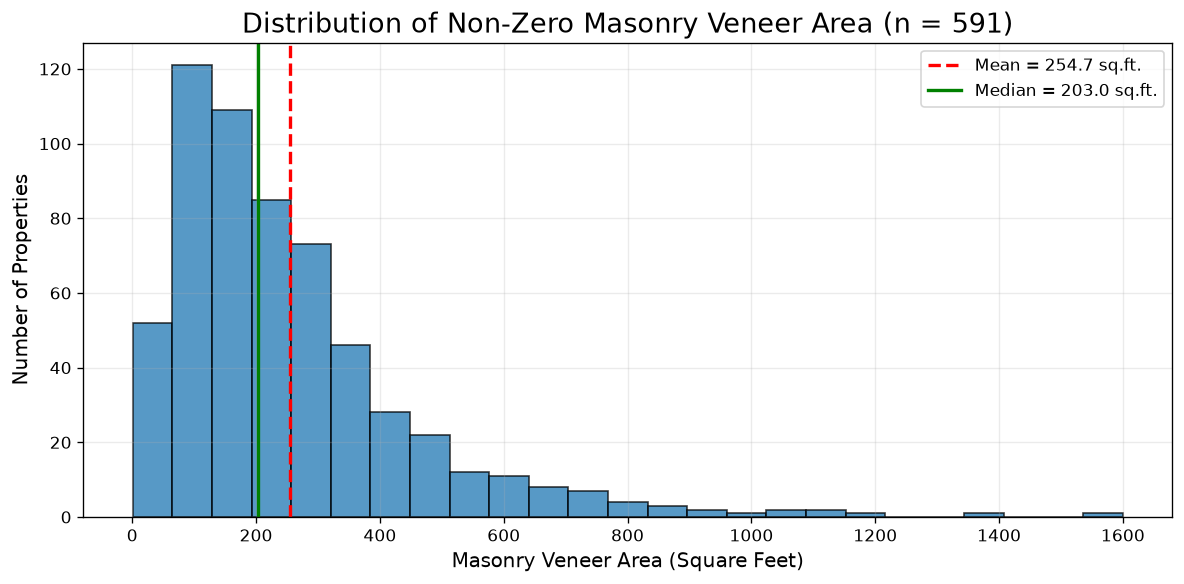

In [19]:
# ============================================================
# Masonry Veneer Analysis
# ============================================================

# Masonry Veneer Type
print("=" * 80)
print("Masonry Veneer Type (MasVnrType)")
print("=" * 80)

display(frequency_table("MasVnrType"))

# ============================================================
# Masonry Veneer Area Statistics
# ============================================================

mas_vnr_area = df["MasVnrArea"].dropna()

print("=" * 80)
print("Masonry Veneer Area - Descriptive Statistics")
print("=" * 80)

display(
    mas_vnr_area.describe().to_frame(name="MasVnrArea Statistics")
)

# ============================================================
# Masonry Veneer Area Distribution (All Properties)
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    mas_vnr_area,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

# Mean
plt.axvline(
    mas_vnr_area.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mas_vnr_area.mean():.1f} sq.ft."
)

# Median
plt.axvline(
    mas_vnr_area.median(),
    color="green",
    linewidth=2,
    label=f"Median = {mas_vnr_area.median():.1f} sq.ft."
)

plt.title(
    f"Distribution of Masonry Veneer Area (All Properties, n = {len(mas_vnr_area)})",
    fontsize=16
)

plt.xlabel("Masonry Veneer Area (Square Feet)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# Masonry Veneer Area Distribution (Non-Zero Values Only)
# ============================================================

non_zero_mas_vnr = df.loc[df["MasVnrArea"] > 0, "MasVnrArea"]

plt.figure(figsize=(10, 5))

plt.hist(
    non_zero_mas_vnr,
    bins=25,
    edgecolor="black",
    alpha=0.75
)

# Mean
plt.axvline(
    non_zero_mas_vnr.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {non_zero_mas_vnr.mean():.1f} sq.ft."
)

# Median
plt.axvline(
    non_zero_mas_vnr.median(),
    color="green",
    linewidth=2,
    label=f"Median = {non_zero_mas_vnr.median():.1f} sq.ft."
)

plt.title(
    f"Distribution of Non-Zero Masonry Veneer Area (n = {len(non_zero_mas_vnr)})",
    fontsize=16
)

plt.xlabel("Masonry Veneer Area (Square Feet)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Observations

#### Categorical Insights

- The **MasVnrType** feature contains a substantial proportion of missing values, with **59.73%** of the observations recorded as missing. This indicates that masonry veneer information is unavailable for many residential properties and should be carefully considered during data preprocessing.
- Among the recorded masonry veneer categories, **Brick Face (BrkFace)** is the most common, accounting for **30.48%** of all properties.
- **Stone** veneer represents **8.77%** of the dataset, whereas **Brick Common (BrkCmn)** is relatively uncommon, appearing in only **1.03%** of the observations.

#### Numerical Insights

- The overall distribution of **MasVnrArea** is highly right-skewed, with the majority of properties having **0 sq.ft.** of masonry veneer. This is reflected by the median value of **0 sq.ft.**
- Although the median is zero, the mean masonry veneer area is approximately **103.69 sq.ft.**, indicating that a relatively small number of properties with large veneer areas increase the overall average.
- When considering only properties with non-zero masonry veneer (**591 properties**), the distribution remains positively skewed. Most veneer areas are concentrated between **100 and 300 sq.ft.**, while a small number of properties exhibit substantially larger veneer areas, extending up to **1600 sq.ft.**
- The difference between the mean (**254.7 sq.ft.**) and median (**203.0 sq.ft.**) for non-zero observations further confirms the influence of larger veneer areas on the overall distribution.

Overall, the masonry veneer features exhibit a combination of substantial missing information, a high proportion of zero-valued observations, and a positively skewed distribution among properties with recorded veneer areas. These characteristics provide important insights into the variability of exterior construction features and should be carefully considered during subsequent preprocessing and feature engineering.

## 8.3 Basement Feature Analysis

This subsection examines the basement-related features to better understand the characteristics of basement quality, condition, exposure, and finishing types across residential properties. Basements represent an important structural component that can significantly influence both the functionality and market value of a house.

The analysis focuses on:

- **BsmtQual** to examine the distribution of basement quality ratings.
- **BsmtCond** to understand the overall condition of basements.
- **BsmtExposure** to analyze the level of basement exposure.
- **BsmtFinType1** and **BsmtFinType2** to investigate the distribution of primary and secondary basement finishing types.

The insights obtained from this analysis provide a comprehensive understanding of basement characteristics and establish a foundation for identifying meaningful patterns before the data preprocessing stage.

In [20]:
# ============================================================
# Basement Feature Analysis
# ============================================================

basement_features = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

for feature in basement_features:

    print("=" * 80)
    print(feature)
    print("=" * 80)

    display(frequency_table(feature))


BsmtQual


,Count,Percentage (%)
BsmtQual,,
TA,649,44.45
Gd,618,42.33
Ex,121,8.29
NaN,37,2.53
Fa,35,2.40


BsmtCond


,Count,Percentage (%)
BsmtCond,,
TA,1311,89.79
Gd,65,4.45
Fa,45,3.08
NaN,37,2.53
Po,2,0.14


BsmtExposure


,Count,Percentage (%)
BsmtExposure,,
No,953,65.27
Av,221,15.14
Gd,134,9.18
Mn,114,7.81
NaN,38,2.60


BsmtFinType1


,Count,Percentage (%)
BsmtFinType1,,
Unf,430,29.45
GLQ,418,28.63
ALQ,220,15.07
BLQ,148,10.14
Rec,133,9.11
LwQ,74,5.07
NaN,37,2.53


BsmtFinType2


,Count,Percentage (%)
BsmtFinType2,,
Unf,1256,86.03
Rec,54,3.70
LwQ,46,3.15
NaN,38,2.60
BLQ,33,2.26
ALQ,19,1.30
GLQ,14,0.96


,Missing Values,Missing Percentage (%)
BsmtQual,37,2.53
BsmtCond,37,2.53
BsmtExposure,38,2.60
BsmtFinType1,37,2.53
BsmtFinType2,38,2.60


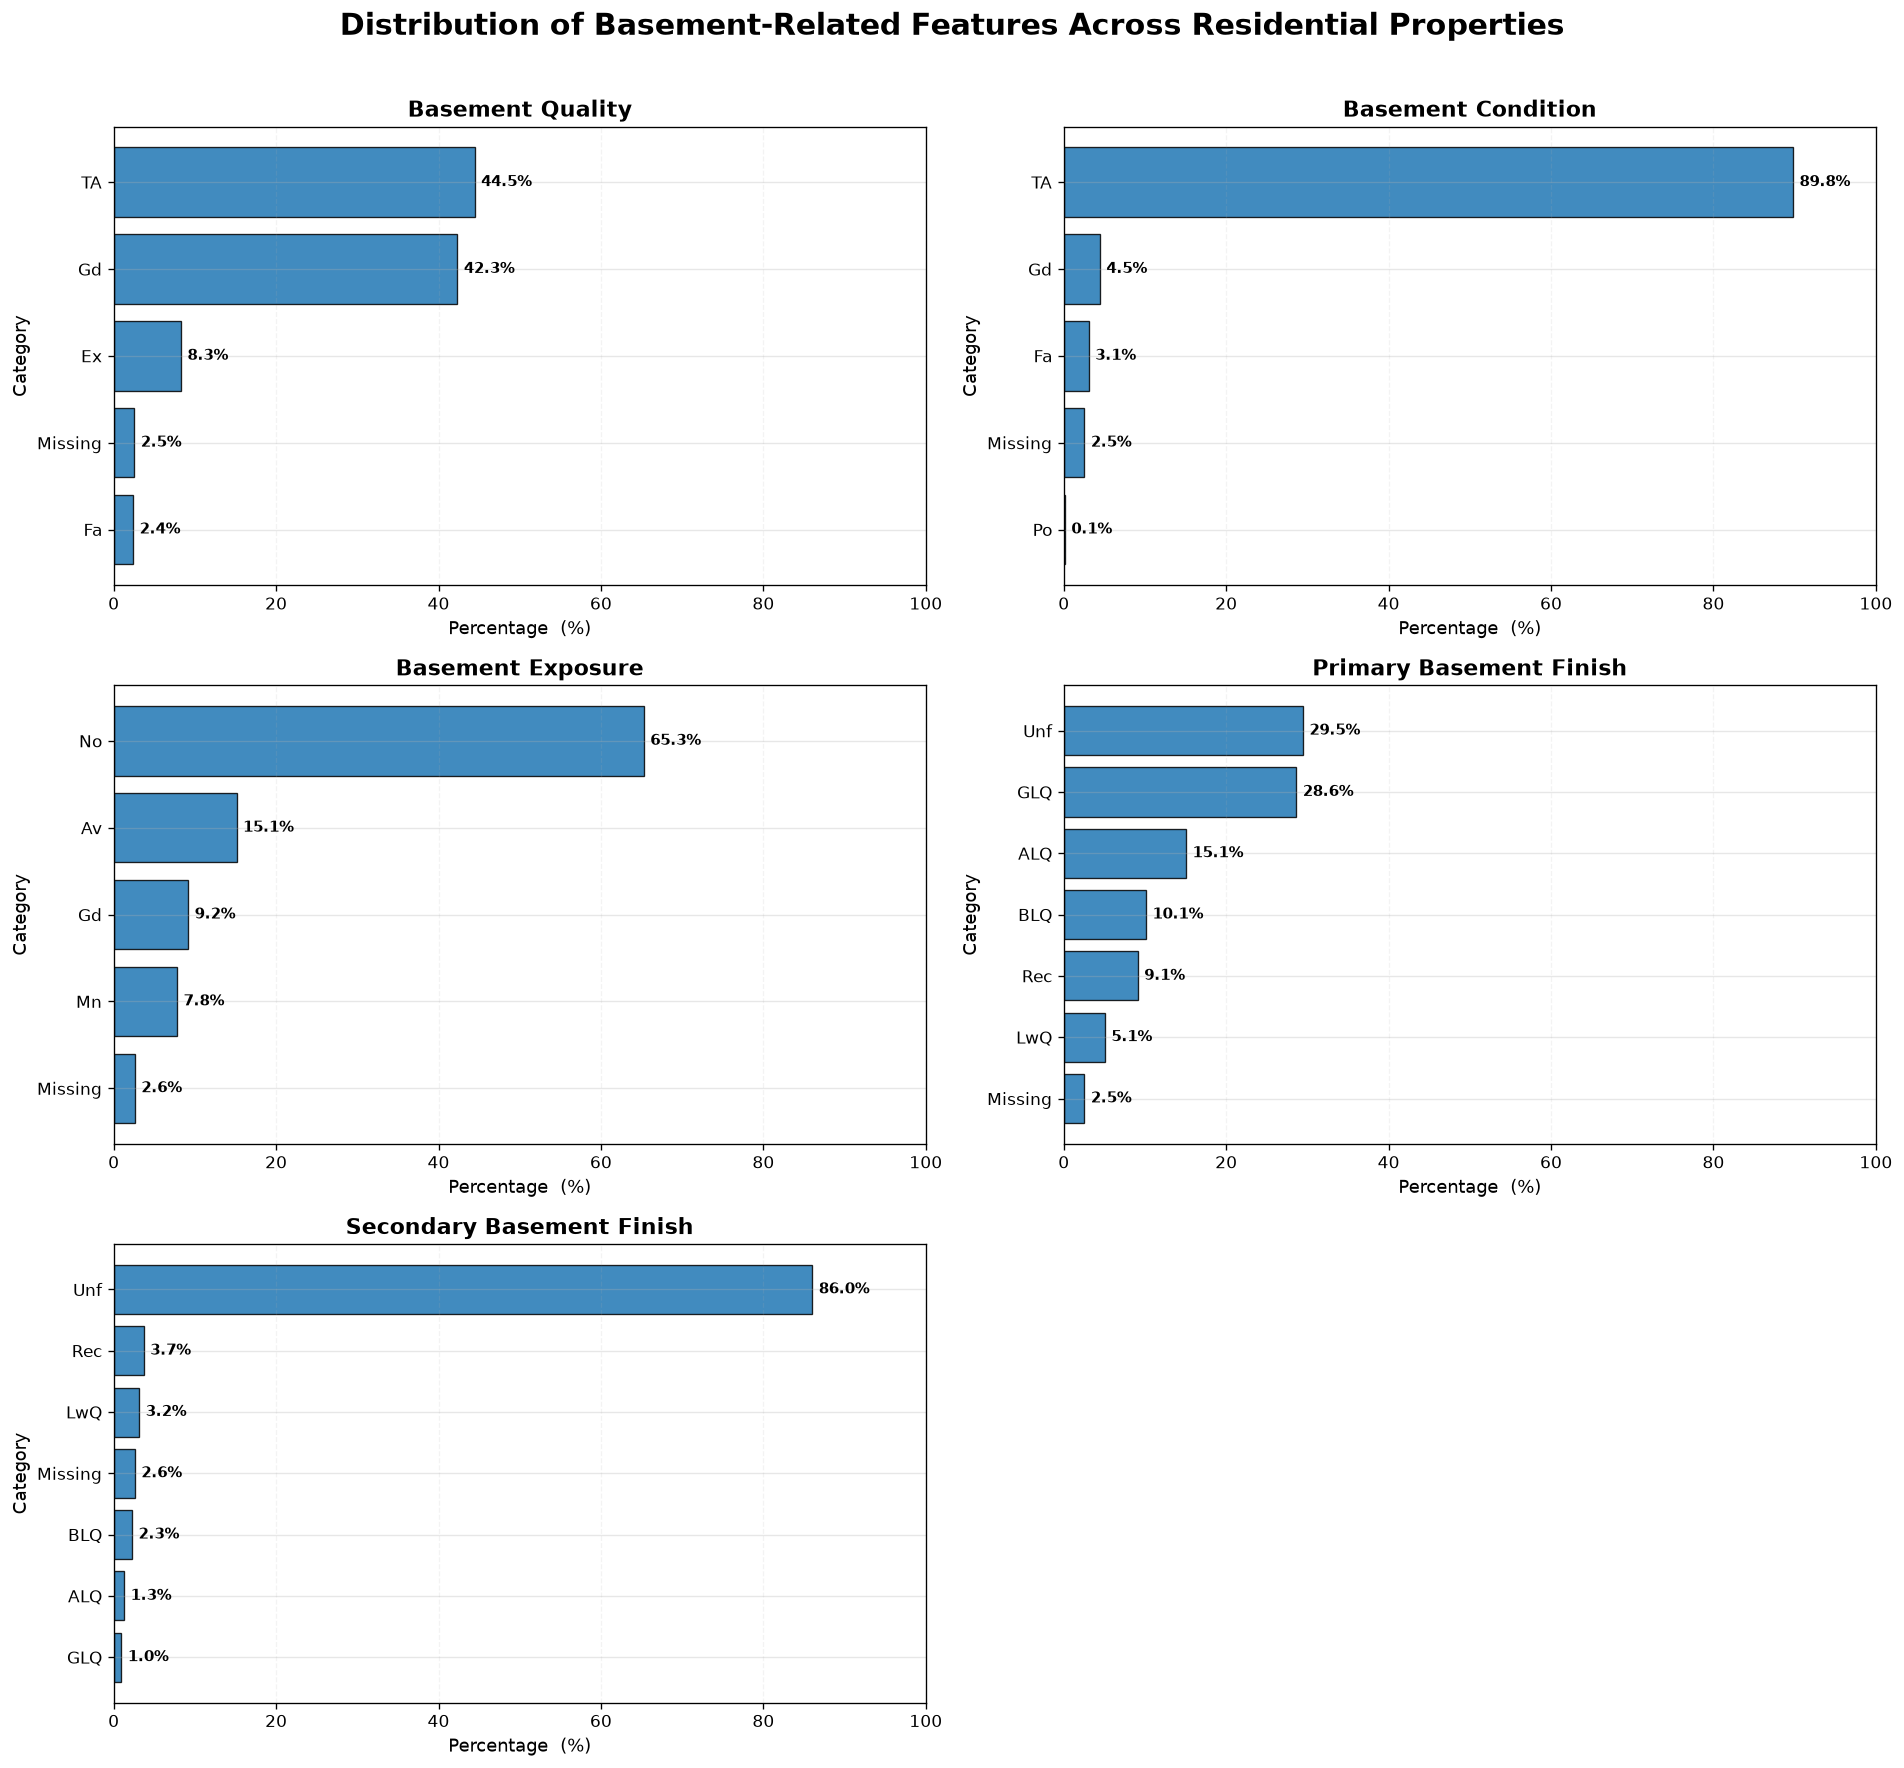

In [21]:
# ============================================================
# Basement Features Summary
# ============================================================

basement_summary = pd.DataFrame({
    "Missing Values": df[basement_features].isnull().sum(),
    "Missing Percentage (%)": (
        df[basement_features]
        .isnull()
        .mean()
        * 100
    ).round(2)
})

display(basement_summary)

# ============================================================
# Basement Features - Distribution Dashboard
# ============================================================

basement_features = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

feature_titles = {
    "BsmtQual": "Basement Quality",
    "BsmtCond": "Basement Condition",
    "BsmtExposure": "Basement Exposure",
    "BsmtFinType1": "Primary Basement Finish",
    "BsmtFinType2": "Secondary Basement Finish"
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 15)
)

axes = axes.flatten()

for i, feature in enumerate(basement_features):

    # Calculate percentage distribution
    percentages = (
        df[feature]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .sort_values(ascending=False)
    )

    # Replace NaN with "Missing"
    labels = [
        "Missing" if pd.isna(x) else str(x)
        for x in percentages.index
    ]

    # Horizontal bar chart
    bars = axes[i].barh(
        labels,
        percentages.values,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85
    )

    # Highest percentage at the top
    axes[i].invert_yaxis()

    # Display percentage labels
    for bar in bars:
        width = bar.get_width()
        axes[i].text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
)

    axes[i].set_xlim(0, 100)

    axes[i].set_title(
    feature_titles[feature],
    fontsize=13,
    fontweight="bold"
)

    axes[i].set_xlabel(
        "Percentage  (%)",
        fontsize=11
    )

    axes[i].set_ylabel(
        "Category",
        fontsize=11
    )

    # Cleaner grid
    axes[i].grid(
        axis="x",
        linestyle="--",
        alpha=0.15
    )

# Remove the unused subplot
fig.delaxes(axes[-1])

# Figure title
plt.suptitle(
    "Distribution of Basement-Related Features Across Residential Properties",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


### Observations

#### Basement Quality and Condition

- The majority of residential properties have basements with **Typical/Average (TA)** or **Good (Gd)** quality, accounting for approximately **86.8%** of all observations. This indicates that most houses possess basements of average to above-average construction quality.
- Basement condition is predominantly rated as **Typical/Average (TA)** (**89.8%**), while only a small proportion of properties are classified as **Good**, **Fair**, or **Poor**. This suggests that basement structures are generally maintained in satisfactory condition across the dataset.

#### Basement Exposure

- Approximately **65.3%** of residential properties have **no basement exposure**, making it the most common exposure category.
- Properties with **Average (Av)**, **Good (Gd)**, and **Minimum (Mn)** exposure collectively represent a considerably smaller proportion of the dataset, indicating that enhanced basement exposure is relatively uncommon.

#### Basement Finishing Characteristics

- For the primary basement finishing type, **Unfinished (Unf)** (**29.5%**) and **Good Living Quarters (GLQ)** (**28.6%**) are the dominant categories, demonstrating substantial variation in how primary basement spaces are utilized.
- In contrast, the secondary basement finishing type is overwhelmingly **Unfinished (86.0%)**, suggesting that most residential properties either do not contain a secondary finished basement area or have left it unfinished.

#### Missing Value Analysis

- All basement-related features exhibit a small and highly consistent proportion of missing values, ranging from **2.5%** to **2.6%** of the dataset.
- The consistency of missing observations across basement quality, condition, exposure, and finishing variables suggests that these records most likely correspond to properties without basements rather than independent data collection errors.

#### Overall Findings

- The exploratory analysis indicates that most residential properties contain basements of **average-to-good quality**, are maintained in **typical condition**, and commonly have **limited exterior exposure**.
- Basement finishing characteristics reveal that while many homes include a finished primary basement area, secondary finished spaces are relatively uncommon.
- Overall, the basement-related features exhibit consistent structural patterns and minimal missing information, making them valuable variables for understanding residential property characteristics during subsequent stages of the analysis.

## 8.4 Garage Feature Analysis

This subsection examines the garage-related features to better understand the characteristics of garage type, finishing status, construction quality, overall condition, capacity, construction year, and floor area across residential properties. Garages are important structural components that enhance property functionality, storage capacity, and market value.

The analysis focuses on:

- **GarageType** to examine the distribution of different garage configurations.
- **GarageFinish** to analyze the completion status of garages.
- **GarageQual** to investigate the construction quality of garages.
- **GarageCond** to understand the overall condition of garages.
- **GarageYrBlt** to explore the construction period of garages.
- **GarageCars** to analyze garage capacity in terms of the number of vehicles accommodated.
- **GarageArea** to examine the distribution of garage floor area.

The insights obtained from this analysis provide a comprehensive understanding of garage-related characteristics and establish a foundation for identifying important structural patterns before the data preprocessing stage.

In [22]:
# ============================================================
# Garage Feature Analysis
# ============================================================

garage_features = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for feature in garage_features:

    print("=" * 80)
    print(feature)
    print("=" * 80)

    display(frequency_table(feature))


GarageType


,Count,Percentage (%)
GarageType,,
Attchd,870,59.59
Detchd,387,26.51
BuiltIn,88,6.03
NaN,81,5.55
Basment,19,1.30
CarPort,9,0.62
2Types,6,0.41


GarageFinish


,Count,Percentage (%)
GarageFinish,,
Unf,605,41.44
RFn,422,28.90
Fin,352,24.11
NaN,81,5.55


GarageQual


,Count,Percentage (%)
GarageQual,,
TA,1311,89.79
NaN,81,5.55
Fa,48,3.29
Gd,14,0.96
Ex,3,0.21
Po,3,0.21


GarageCond


,Count,Percentage (%)
GarageCond,,
TA,1326,90.82
NaN,81,5.55
Fa,35,2.40
Gd,9,0.62
Po,7,0.48
Ex,2,0.14


In [23]:
# ============================================================
# Garage Features Summary
# ============================================================

garage_summary = pd.DataFrame({
    "Missing Values": df[garage_features].isnull().sum(),
    "Missing Percentage (%)": (
        df[garage_features]
        .isnull()
        .mean()
        * 100
    ).round(2)
})

display(garage_summary)


,Missing Values,Missing Percentage (%)
GarageType,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55
GarageCond,81,5.55


In [24]:
# ============================================================
# Garage Numerical Features Summary
# ============================================================

garage_numerical = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea"
]

garage_statistics = pd.DataFrame({
    "Missing Values": df[garage_numerical].isnull().sum(),
    "Missing Percentage (%)": (
        df[garage_numerical]
        .isnull()
        .mean()
        * 100
    ).round(2),
    "Mean": df[garage_numerical].mean().round(2),
    "Median": df[garage_numerical].median().round(2),
    "Std": df[garage_numerical].std().round(2),
    "Minimum": df[garage_numerical].min(),
    "Maximum": df[garage_numerical].max()
})

display(garage_statistics)


,Missing Values,Missing Percentage (%),Mean,Median,Std,Minimum,Maximum
GarageYrBlt,81,5.55,1978.51,1980.00,24.69,1900.00,2010.00
GarageCars,0,0.00,1.77,2.00,0.75,0.00,4.00
GarageArea,0,0.00,472.98,480.00,213.80,0.00,1418.00


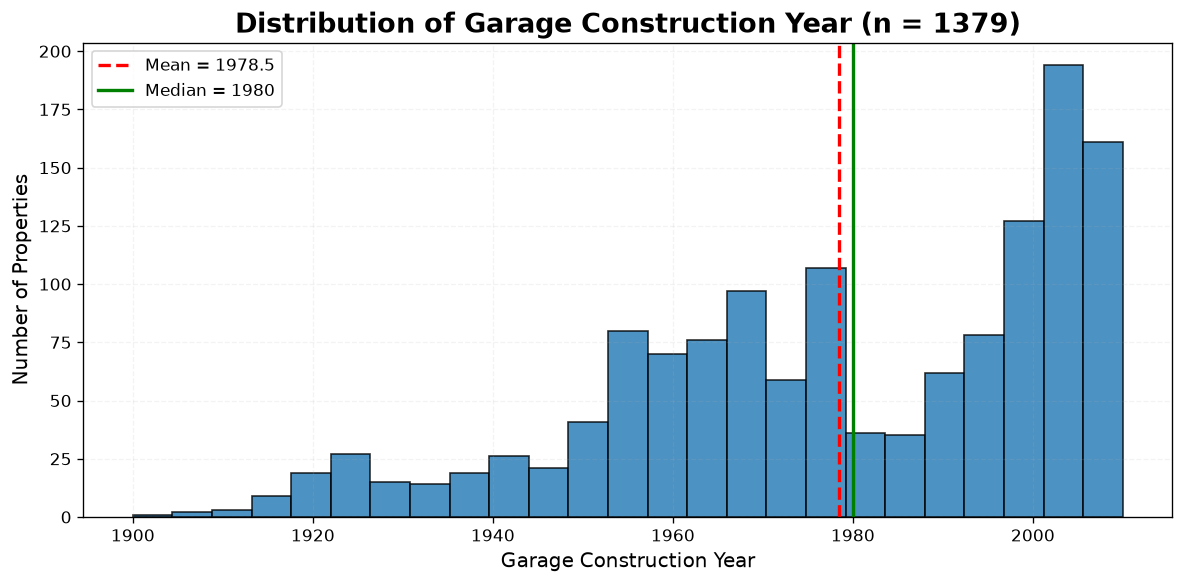

In [25]:
# ============================================================
# Distribution of Garage Construction Year
# ============================================================

garage_year = df["GarageYrBlt"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    garage_year,
    bins=25,
    edgecolor="black",
    alpha=0.8
)

# Mean
plt.axvline(
    garage_year.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {garage_year.mean():.1f}"
)

# Median
plt.axvline(
    garage_year.median(),
    color="green",
    linewidth=2,
    label=f"Median = {garage_year.median():.0f}"
)

plt.title(
    f"Distribution of Garage Construction Year (n = {len(garage_year)})",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Garage Construction Year", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.grid(
    alpha=0.15,
    linestyle="--"
)

plt.legend()

plt.tight_layout()

plt.show()


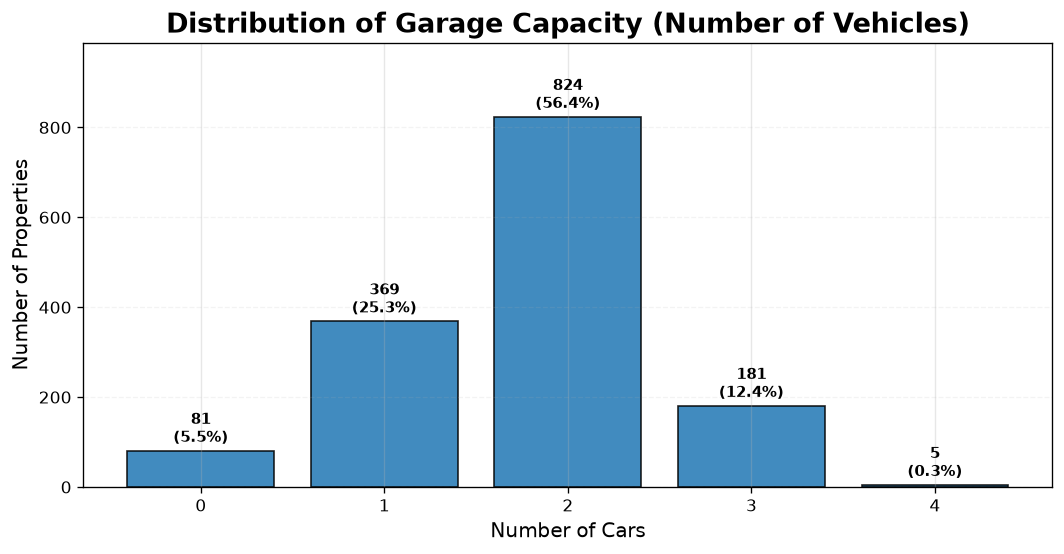

In [26]:
# ============================================================
# Distribution of Garage Capacity
# ============================================================

garage_cars_counts = (
    df["GarageCars"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    garage_cars_counts.index.astype(int).astype(str),
    garage_cars_counts.values,
    edgecolor="black",
    alpha=0.85
)

# Add 20% extra space above the tallest bar
y_max = max(garage_cars_counts.values)
plt.ylim(0, y_max * 1.20)

# Annotate each bar
for bar in bars:

    count = int(bar.get_height())
    percentage = (count / len(df)) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + (0.01 * y_max),   # Dynamic spacing
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Distribution of Garage Capacity (Number of Vehicles)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Cars",
    fontsize=12
)

plt.ylabel(
    "Number of Properties",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


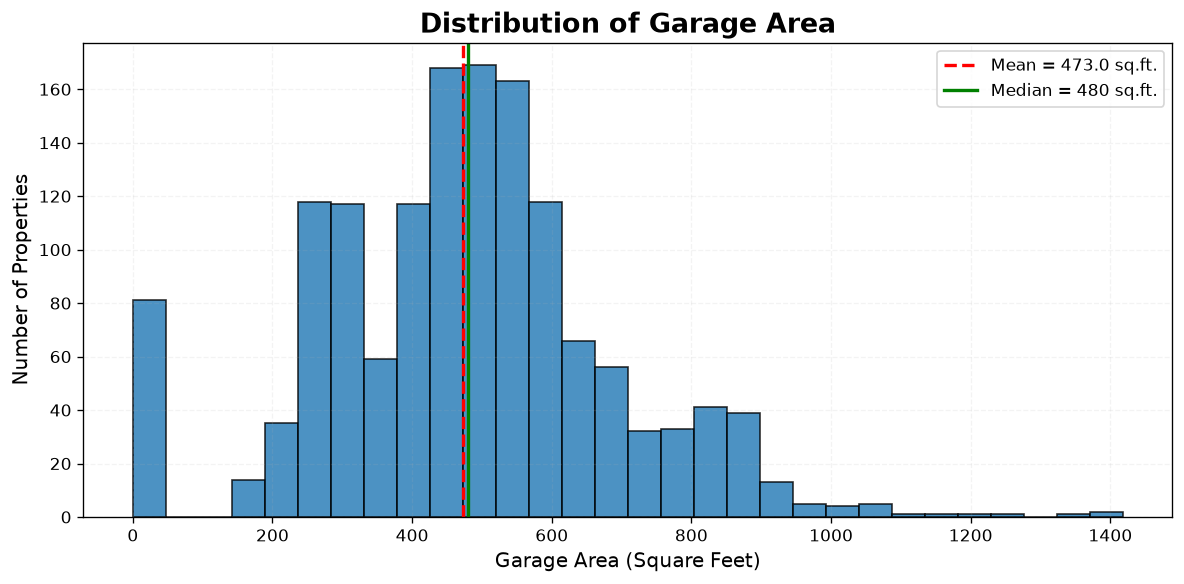

In [27]:
# ============================================================
# Distribution of Garage Area
# ============================================================

garage_area = df["GarageArea"]

plt.figure(figsize=(10, 5))

plt.hist(
    garage_area,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    garage_area.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {garage_area.mean():.1f} sq.ft."
)

plt.axvline(
    garage_area.median(),
    color="green",
    linewidth=2,
    label=f"Median = {garage_area.median():.0f} sq.ft."
)

plt.title(
    "Distribution of Garage Area",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Garage Area (Square Feet)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

plt.grid(
    alpha=0.15,
    linestyle="--"
)

plt.legend()

plt.tight_layout()

plt.show()


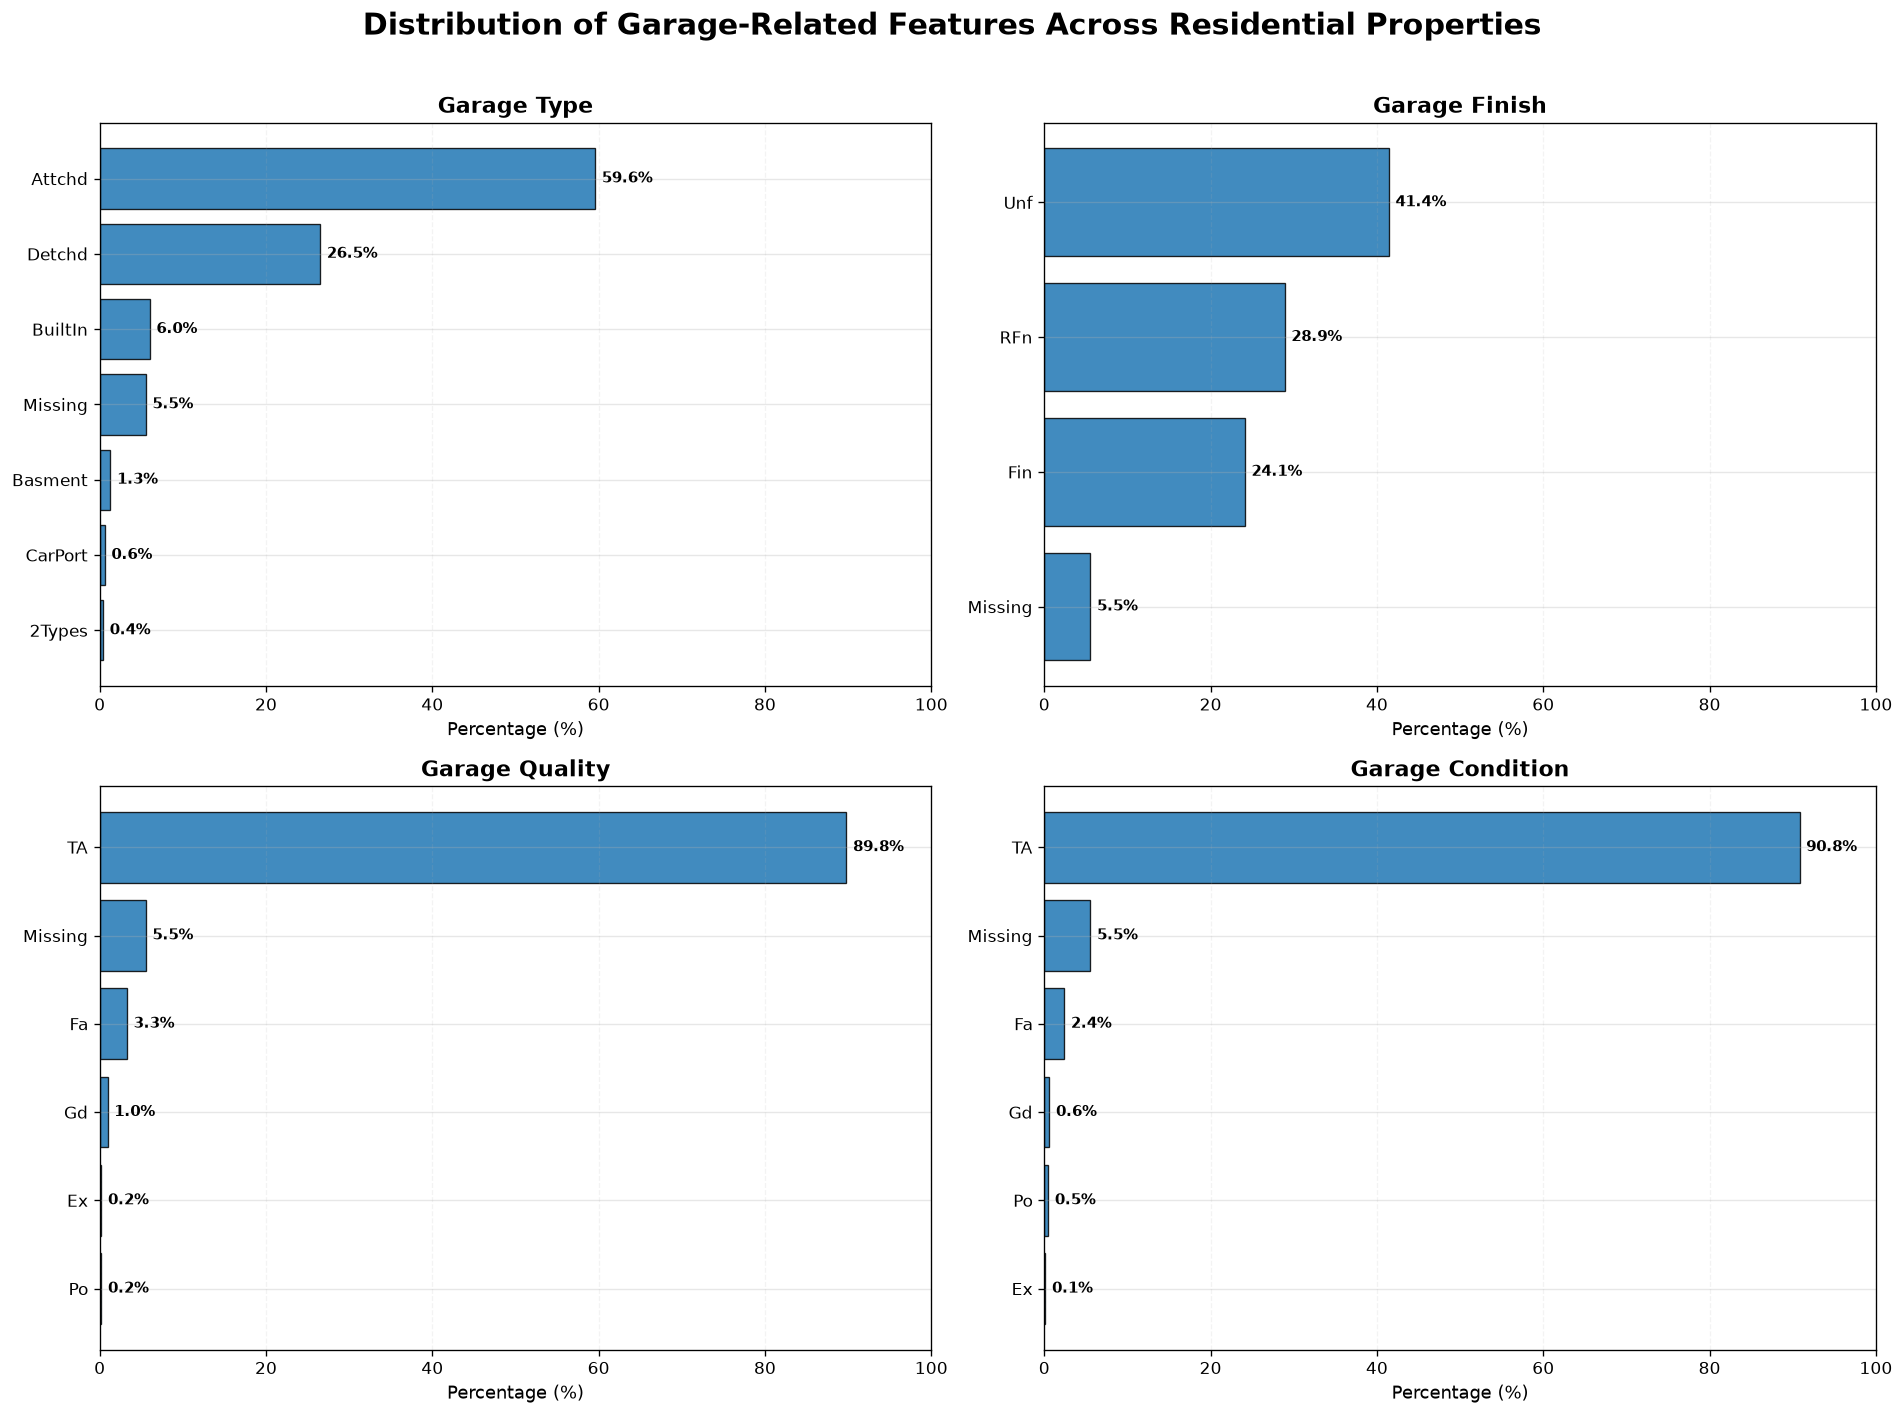

In [28]:
# ============================================================
# Garage Features - Distribution Dashboard
# ============================================================

garage_features = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

feature_titles = {
    "GarageType": "Garage Type",
    "GarageFinish": "Garage Finish",
    "GarageQual": "Garage Quality",
    "GarageCond": "Garage Condition"
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, feature in enumerate(garage_features):

    percentages = (
        df[feature]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .sort_values(ascending=False)
    )

    labels = [
        "Missing" if pd.isna(x) else str(x)
        for x in percentages.index
    ]

    bars = axes[i].barh(
        labels,
        percentages.values,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85
    )

    # Highest percentage at the top
    axes[i].invert_yaxis()

    # Percentage labels
    for bar in bars:

        width = bar.get_width()

        axes[i].text(
            width + 0.8,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold"
        )

    axes[i].set_xlim(0, 100)

    axes[i].set_title(
        feature_titles[feature],
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel(
        "Percentage (%)",
        fontsize=11
    )

    axes[i].set_ylabel("")

    axes[i].grid(
        axis="x",
        linestyle="--",
        alpha=0.15
    )

plt.suptitle(
    "Distribution of Garage-Related Features Across Residential Properties",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


### Observations

#### Garage Type

- **Attached garages (Attchd)** are the most common configuration, representing approximately **59.6%** of all residential properties. Detached garages (**26.5%**) are the second most common type, while built-in, basement, carport, and multiple-type garages collectively account for a relatively small proportion of the dataset.
- Approximately **5.5%** of the observations contain missing garage-related information, which is consistent across all garage categorical features and likely corresponds to properties without garages.

#### Garage Finish

- **Unfinished (Unf)** garages represent the largest category (**41.4%**), followed by **Rough Finished (RFn)** (**28.9%**) and **Finished (Fin)** (**24.1%**).
- This distribution suggests that although garages are common among residential properties, a substantial proportion remain partially or completely unfinished.

#### Garage Quality and Condition

- The majority of garages are rated as **Typical/Average (TA)** in both construction quality (**89.8%**) and overall condition (**90.8%**), indicating that most garages provide standard structural quality and maintenance.
- Ratings of **Excellent (Ex)**, **Good (Gd)**, **Fair (Fa)**, and **Poor (Po)** collectively represent only a small fraction of the dataset, suggesting limited variability in garage quality and condition.

#### Garage Construction Year

- Garage construction years range from **1900 to 2010**, with the majority of garages constructed after the **1950s**.
- The distribution exhibits a noticeable concentration of garages built during the late twentieth and early twenty-first centuries.
- The **mean construction year (1978.5)** and **median construction year (1980)** are very close, indicating only slight skewness in the distribution.

#### Garage Capacity

- **Two-car garages** are the most common, accounting for approximately **56.4%** of residential properties.
- **One-car garages (25.3%)** and **three-car garages (12.4%)** are also relatively common, whereas properties with **four-car garages (0.3%)** are rare.
- Approximately **5.5%** of the properties have **no garage capacity**, which aligns closely with the proportion of missing garage-related categorical information.

#### Garage Area

- Garage floor areas are concentrated around **480 square feet**, with a **mean of approximately 473 square feet** and a **median of 480 square feet**.
- The distribution exhibits a slight positive skew due to a small number of properties with exceptionally large garages.
- Most residential properties have moderate-sized garages, while extremely large garage areas are relatively uncommon.

#### Overall Findings

- The exploratory analysis indicates that most residential properties possess **attached garages** with **typical construction quality and condition**, **moderate floor area**, and a **capacity for two vehicles**.
- Garage-related features exhibit relatively low levels of missing information, and the consistent missing-value pattern suggests that these observations primarily correspond to properties without garages.
- Overall, the garage variables provide valuable structural information that is likely to contribute meaningfully to understanding residential property characteristics during subsequent stages of the analysis.

## 8.5 High-Impact Feature Analysis

This subsection investigates the most influential features identified during the correlation analysis. These variables exhibit the strongest relationships with the target variable (**SalePrice**) and therefore play an important role in explaining variations in residential property prices.

The analysis focuses on the following features:

- **OverallQual** to examine the overall material and construction quality of residential properties.
- **GrLivArea** to analyze above-ground living area.
- **TotalBsmtSF** to investigate total basement area.
- **1stFlrSF** to examine first-floor living area.
- **FullBath** to analyze the number of full bathrooms.
- **YearBuilt** to explore the construction period of residential properties.
- **YearRemodAdd** to investigate renovation and remodeling trends.

The objective of this analysis is to understand the distributions, structural characteristics, and potential influence of these highly correlated variables before proceeding to the data preprocessing and feature engineering stages.

In [29]:
# ============================================================
# High-Impact Feature Summary
# ============================================================

important_features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "YearBuilt",
    "YearRemodAdd"
]

important_summary = pd.DataFrame({
    "Missing Values": df[important_features].isnull().sum(),
    "Missing Percentage (%)": (
        df[important_features]
        .isnull()
        .mean()
        * 100
    ).round(2),
    "Mean": df[important_features].mean().round(2),
    "Median": df[important_features].median().round(2),
    "Std": df[important_features].std().round(2),
    "Minimum": df[important_features].min(),
    "Maximum": df[important_features].max()
})

display(important_summary)


,Missing Values,Missing Percentage (%),Mean,Median,Std,Minimum,Maximum
OverallQual,0,0.00,6.10,6.00,1.38,1,10
GrLivArea,0,0.00,1515.46,1464.00,525.48,334,5642
TotalBsmtSF,0,0.00,1057.43,991.50,438.71,0,6110
1stFlrSF,0,0.00,1162.63,1087.00,386.59,334,4692
FullBath,0,0.00,1.57,2.00,0.55,0,3
YearBuilt,0,0.00,1971.27,1973.00,30.20,1872,2010
YearRemodAdd,0,0.00,1984.87,1994.00,20.65,1950,2010


In [30]:
# ============================================================
# Correlation with SalePrice
# ============================================================

top_features = (
    saleprice_correlation
    .loc[important_features]
    .sort_values(
        by="Correlation Strength",
        ascending=False
    )
)

display(
    top_features.style.format({
        "Correlation Coefficient": "{:.3f}",
        "Correlation Strength": "{:.3f}"
    })
)


,Correlation Coefficient,Correlation Strength
OverallQual,0.791,0.791
GrLivArea,0.709,0.709
TotalBsmtSF,0.614,0.614
1stFlrSF,0.606,0.606
FullBath,0.561,0.561
YearBuilt,0.523,0.523
YearRemodAdd,0.507,0.507


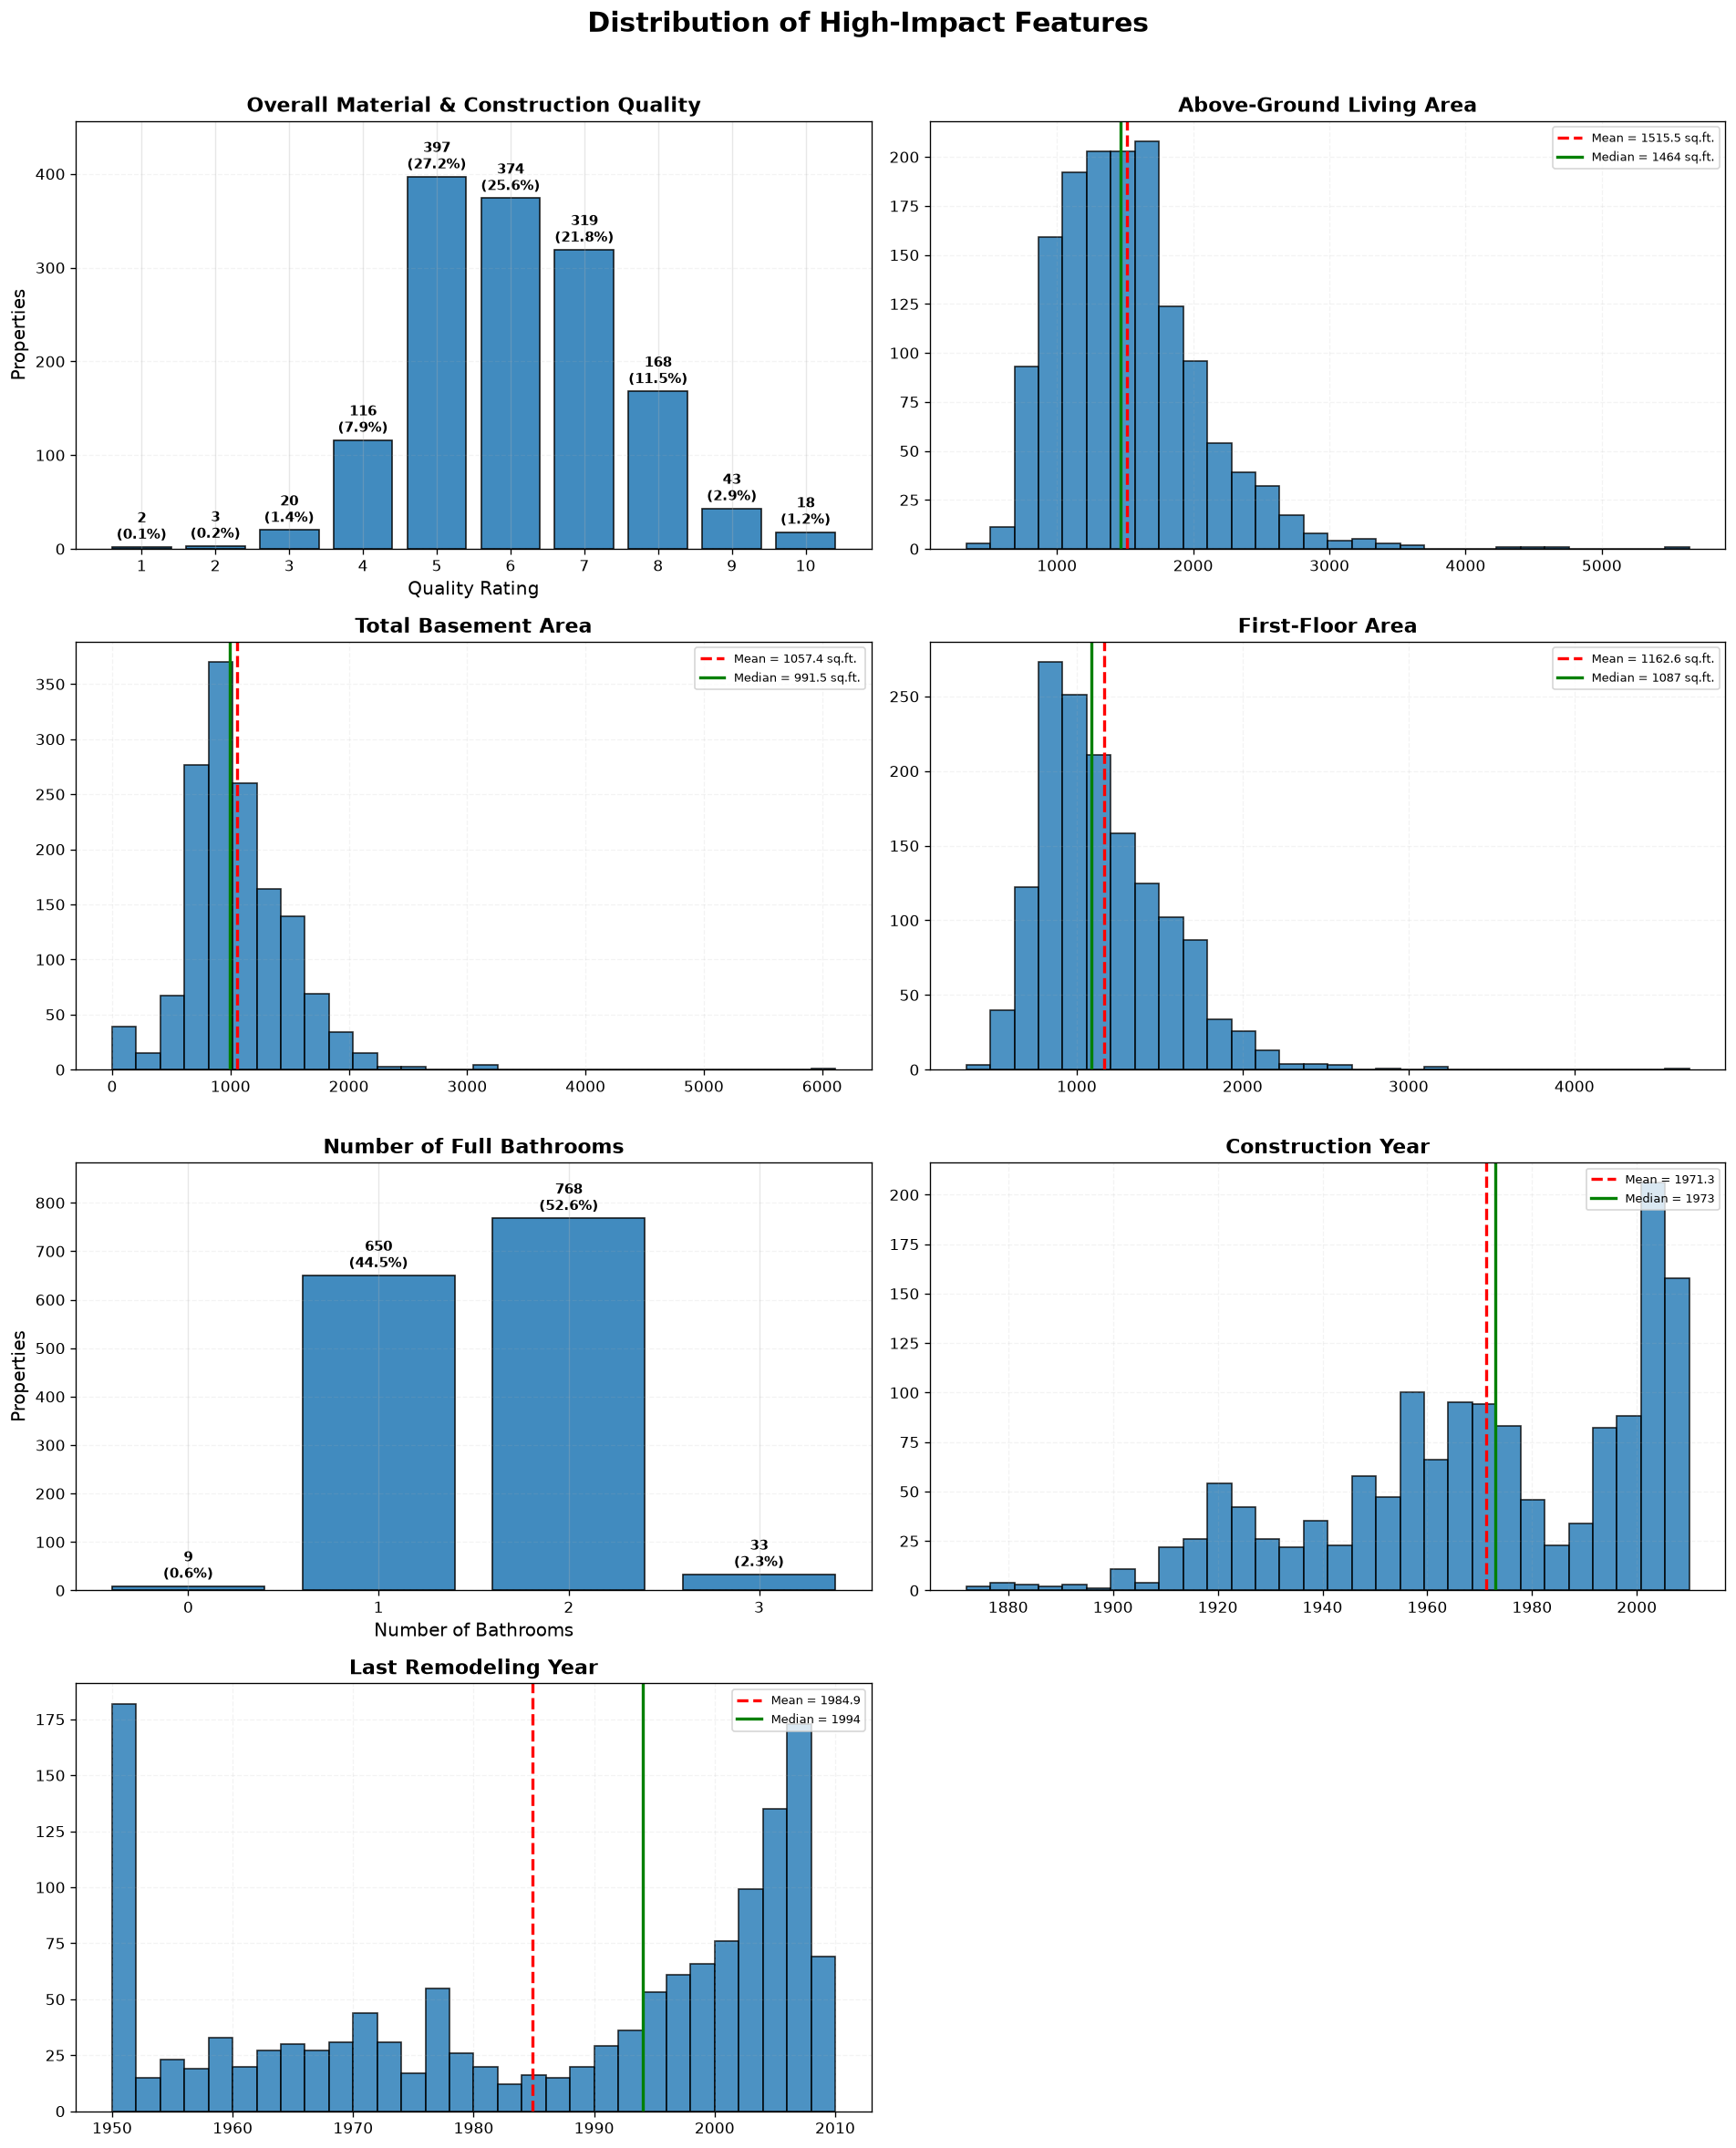

In [31]:
# ============================================================
# High-Impact Feature Dashboard
# ============================================================

fig, axes = plt.subplots(
    4,
    2,
    figsize=(16, 20)
)

axes = axes.flatten()

# ============================================================
# 1. Overall Material & Construction Quality
# ============================================================

overall_quality = (
    df["OverallQual"]
    .value_counts()
    .sort_index()
)

bars = axes[0].bar(
    overall_quality.index.astype(str),
    overall_quality.values,
    edgecolor="black",
    alpha=0.85
)

# Add labels (Count + Percentage)
y_max = max(overall_quality.values)
axes[0].set_ylim(0, y_max * 1.15)

for bar in bars:

    count = int(bar.get_height())
    percentage = (count / len(df)) * 100

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + (0.01 * y_max),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axes[0].set_title(
    "Overall Material & Construction Quality",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Quality Rating")
axes[0].set_ylabel("Properties")

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

# ============================================================
# 2. Above Ground Living Area
# ============================================================

living_area = df["GrLivArea"]

axes[1].hist(
    living_area,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[1].axvline(
    living_area.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {living_area.mean():.1f} sq.ft."
)

axes[1].axvline(
    living_area.median(),
    color="green",
    linewidth=2,
    label=f"Median = {living_area.median():.0f} sq.ft."
)

axes[1].set_title(
    "Above-Ground Living Area",
    fontsize=13,
    fontweight="bold"
)

axes[1].grid(
    linestyle="--",
    alpha=0.15
)

axes[1].legend(
    fontsize=8,
    loc="upper right"
)

# ============================================================
# 3. Total Basement Area
# ============================================================

basement = df["TotalBsmtSF"]

axes[2].hist(
    basement,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[2].axvline(
    basement.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {basement.mean():.1f} sq.ft."
)

axes[2].axvline(
    basement.median(),
    color="green",
    linewidth=2,
    label=f"Median = {basement.median():.1f} sq.ft."
)

axes[2].set_title(
    "Total Basement Area",
    fontsize=13,
    fontweight="bold"
)

axes[2].grid(
    linestyle="--",
    alpha=0.15
)

axes[2].legend(
    fontsize=8,
    loc="upper right"
)

# ============================================================
# 4. First Floor Area
# ============================================================

first_floor = df["1stFlrSF"]

axes[3].hist(
    first_floor,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[3].axvline(
    first_floor.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {first_floor.mean():.1f} sq.ft."
)

axes[3].axvline(
    first_floor.median(),
    color="green",
    linewidth=2,
    label=f"Median = {first_floor.median():.0f} sq.ft."
)

axes[3].set_title(
    "First-Floor Area",
    fontsize=13,
    fontweight="bold"
)

axes[3].grid(
    linestyle="--",
    alpha=0.15
)

axes[3].legend(
    fontsize=8,
    loc="upper right"
)

# ============================================================
# 5. Number of Full Bathrooms
# ============================================================

bathrooms = (
    df["FullBath"]
    .value_counts()
    .sort_index()
)

bars = axes[4].bar(
    bathrooms.index.astype(str),
    bathrooms.values,
    edgecolor="black",
    alpha=0.85
)

# Add labels (Count + Percentage)
y_max = max(bathrooms.values)
axes[4].set_ylim(0, y_max * 1.15)

for bar in bars:

    count = int(bar.get_height())
    percentage = (count / len(df)) * 100

    axes[4].text(
        bar.get_x() + bar.get_width() / 2,
        count + (0.01 * y_max),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axes[4].set_title(
    "Number of Full Bathrooms",
    fontsize=13,
    fontweight="bold"
)

axes[4].set_xlabel("Number of Bathrooms")
axes[4].set_ylabel("Properties")

axes[4].grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

# ============================================================
# 6. Construction Year
# ============================================================

year_built = df["YearBuilt"]

axes[5].hist(
    year_built,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[5].axvline(
    year_built.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {year_built.mean():.1f}"
)

axes[5].axvline(
    year_built.median(),
    color="green",
    linewidth=2,
    label=f"Median = {year_built.median():.0f}"
)

axes[5].set_title(
    "Construction Year",
    fontsize=13,
    fontweight="bold"
)

axes[5].grid(
    linestyle="--",
    alpha=0.15
)

axes[5].legend(
    fontsize=8,
    loc="upper right"
)

# ============================================================
# 7. Last Remodeling Year
# ============================================================

remodel = df["YearRemodAdd"]

axes[6].hist(
    remodel,
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[6].axvline(
    remodel.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {remodel.mean():.1f}"
)

axes[6].axvline(
    remodel.median(),
    color="green",
    linewidth=2,
    label=f"Median = {remodel.median():.0f}"
)

axes[6].set_title(
    "Last Remodeling Year",
    fontsize=13,
    fontweight="bold"
)

axes[6].grid(
    linestyle="--",
    alpha=0.15
)

axes[6].legend(
    fontsize=8,
    loc="upper right"
)

# Remove empty subplot
fig.delaxes(axes[7])

plt.suptitle(
    "Distribution of High-Impact Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


# 8.6 Summary of Exploratory Data Analysis (EDA)

This section summarizes the key findings obtained from the exploratory analysis of the Ames Housing dataset. The objective is to consolidate the major observations regarding data quality, feature characteristics, and relationships with the target variable before proceeding to the data preprocessing stage.

The exploratory analysis provided valuable insights into the structure of the dataset, identified important predictive variables, examined missing-value patterns, and highlighted the overall characteristics of residential properties. These findings establish a strong analytical foundation for feature engineering, data preprocessing, and predictive model development in the subsequent stages of this project.

## Key Findings

### Dataset Quality

- The dataset contains **1,460 residential properties** described by **81 features**, providing a comprehensive representation of structural, locational, and quality-related housing characteristics.
- Duplicate records were not identified, indicating that each observation represents a unique residential property.
- Missing values are concentrated within a limited number of features and primarily correspond to the absence of specific property attributes rather than data collection errors.

---

### Target Variable Characteristics

- The target variable (**SalePrice**) exhibits a positively skewed distribution, indicating the presence of a relatively small number of high-value residential properties.
- Most properties are concentrated within the lower and middle price ranges, while luxury homes form the upper tail of the distribution.

---

### Feature Relationships

Correlation analysis identified several variables with strong positive relationships with residential property prices.

The most influential features include:

| Feature | Correlation with SalePrice |
|:---------|--------------------------:|
| OverallQual | 0.791 |
| GrLivArea | 0.709 |
| GarageCars | 0.640 |
| GarageArea | 0.623 |
| TotalBsmtSF | 0.614 |
| 1stFlrSF | 0.606 |
| FullBath | 0.561 |
| YearBuilt | 0.523 |
| YearRemodAdd | 0.507 |

These variables are expected to play a significant role during predictive model development.

---

### Structural Feature Analysis

The exploratory analysis revealed several important structural characteristics of residential properties:

- Most houses possess attached garages with capacity for approximately two vehicles.
- Garage quality and condition are predominantly rated as typical or average.
- Basement-related features indicate that the majority of houses have finished basement areas with average construction quality.
- Masonry veneer is absent in many properties, while those containing masonry veneer generally exhibit moderate surface areas.
- Residential construction activity increased substantially after the mid-twentieth century, with many properties undergoing remodeling during recent decades.

---

### High-Impact Features

The most influential predictors identified during exploratory analysis exhibit the following characteristics:

- Overall construction quality is concentrated between ratings of five and seven.
- Above-ground living area, first-floor area, and basement area display moderate positive skewness with relatively few extreme observations.
- Most residential properties contain one or two full bathrooms.
- Construction year and remodeling year indicate continued residential development and modernization over time.

---

### Implications for Data Preprocessing

The exploratory analysis indicates that the dataset is generally clean and well-structured; however, several preprocessing tasks remain necessary before model development, including:

- Handling missing values.
- Encoding categorical variables.
- Feature engineering.
- Scaling numerical variables where appropriate.
- Detecting and treating influential outliers.
- Preparing the dataset for machine learning algorithms.

These tasks will be performed in the next notebook, **02_data_preprocessing.ipynb**.

---

### Conclusion

The exploratory data analysis successfully established a comprehensive understanding of the Ames Housing dataset by examining data quality, feature distributions, structural property characteristics, and relationships with the target variable. The insights obtained during this phase provide a strong analytical foundation for the subsequent preprocessing, feature engineering, and predictive modeling stages of the Smart House Price Prediction project.

01_data_understanding.ipynb

1. Introduction
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Data Quality Assessment
6. Target Variable Analysis
7. Correlation Analysis

8. Exploratory Data Analysis (EDA)

   8.1 Exploratory Analysis of Key Features
   8.2 Masonry Veneer Analysis
   8.3 Basement Feature Analysis
   8.4 Garage Feature Analysis
   8.5 High-Impact Feature Analysis
   8.6 Summary of EDA Findings